In [9]:
# !pip install nba_api
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguedashteamstats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Function to get and save team data to CSV
def get_and_save_team_data():
    try:
        team_stats = leaguedashteamstats.LeagueDashTeamStats(
            season='2024-25', 
            season_type_all_star='Regular Season',
            per_mode_detailed='PerGame'
        )        
        df = team_stats.get_data_frames()[0]
        
        df.to_csv('nba_team_data.csv', index=False)
        print("Data saved to 'nba_team_data.csv'")
        
        return df
        
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

Fetching data from API...
{"resource":"leaguedashteamstats","parameters":{"MeasureType":"Base","PerMode":"PerGame","PlusMinus":"N","PaceAdjust":"N","Rank":"N","LeagueID":"00","Season":"2024-25","SeasonType":"Regular Season","PORound":null,"Outcome":null,"Location":null,"Month":0,"SeasonSegment":null,"DateFrom":null,"DateTo":null,"OpponentTeamID":0,"VsConference":null,"VsDivision":null,"TeamID":null,"Conference":null,"Division":null,"GameSegment":null,"Period":0,"ShotClockRange":null,"LastNGames":0,"GameScope":null,"PlayerExperience":null,"PlayerPosition":null,"StarterBench":null,"TwoWay":0,"GameSubtype":null,"ISTRound":null},"resultSets":[{"name":"LeagueDashTeamStats","headers":["TEAM_ID","TEAM_NAME","GP","W","L","W_PCT","MIN","FGM","FGA","FG_PCT","FG3M","FG3A","FG3_PCT","FTM","FTA","FT_PCT","OREB","DREB","REB","AST","TOV","STL","BLK","BLKA","PF","PFD","PTS","PLUS_MINUS","GP_RANK","W_RANK","L_RANK","W_PCT_RANK","MIN_RANK","FGM_RANK","FGA_RANK","FG_PCT_RANK","FG3M_RANK","FG3A_RANK","FG3

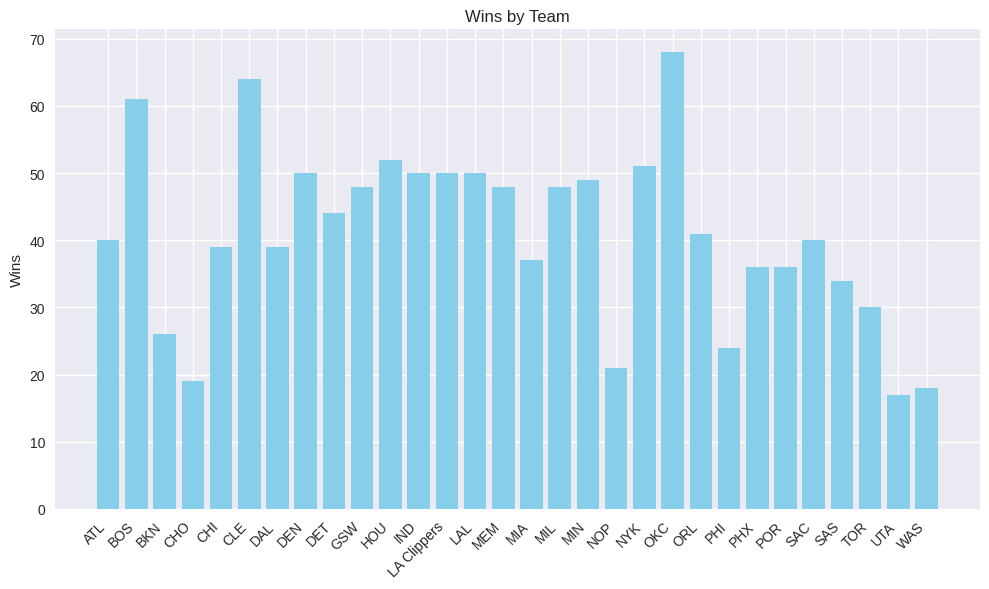

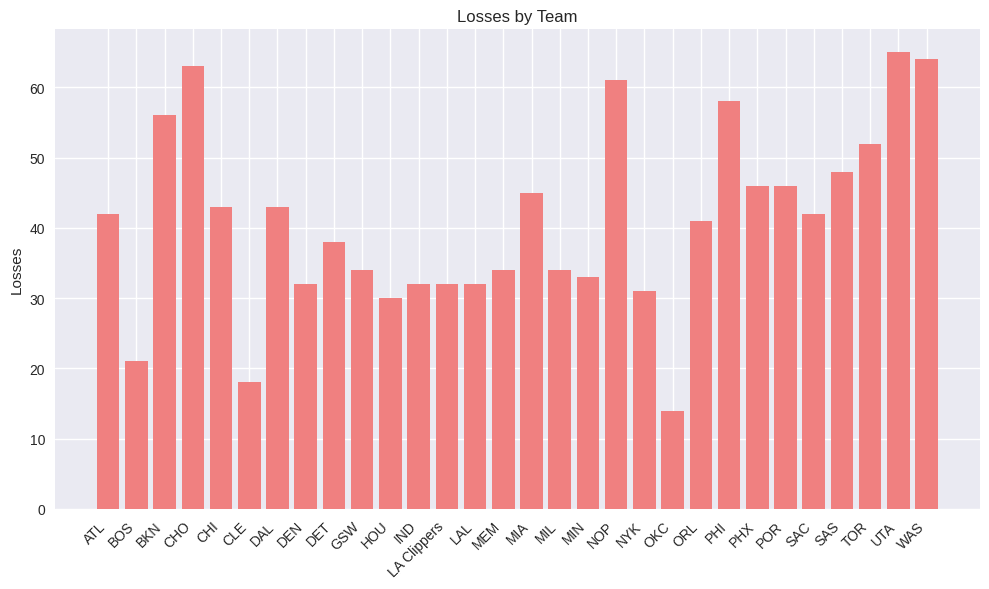

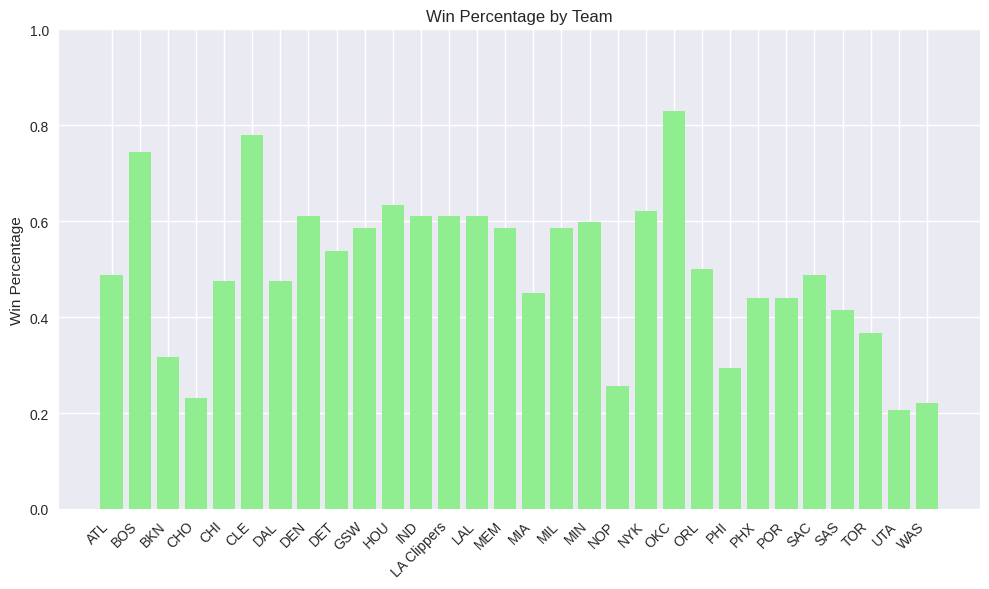

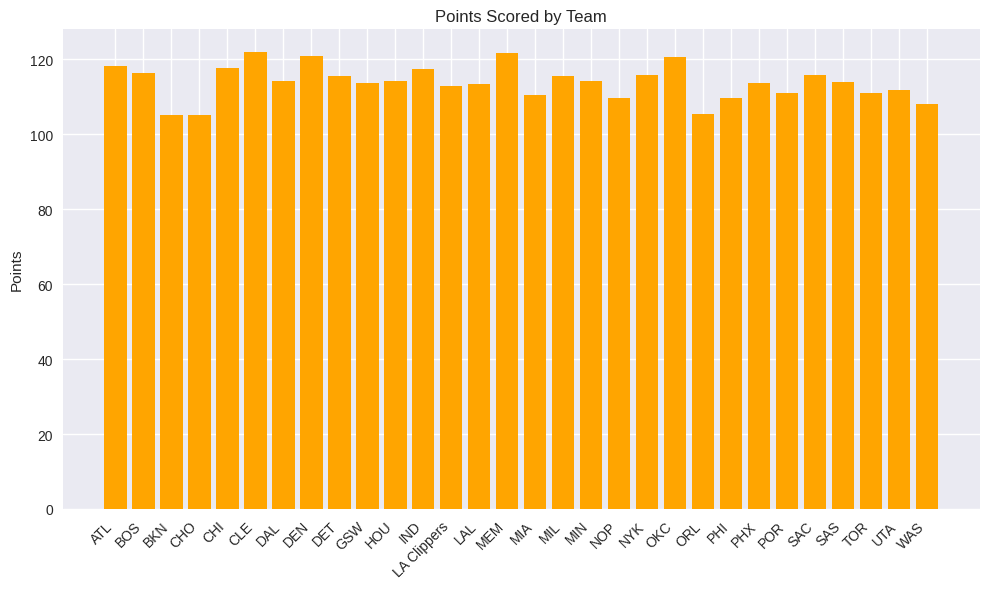

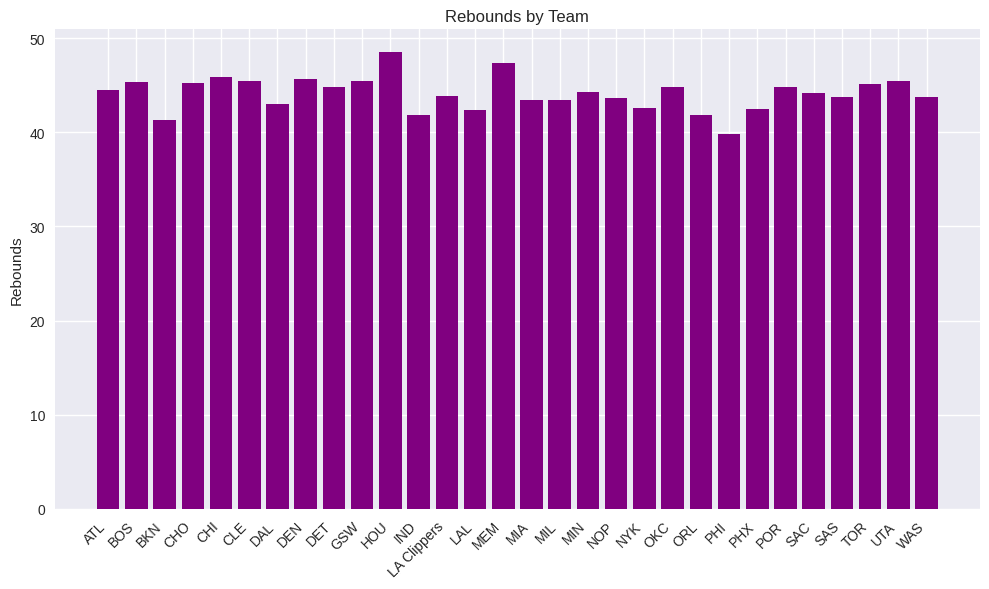

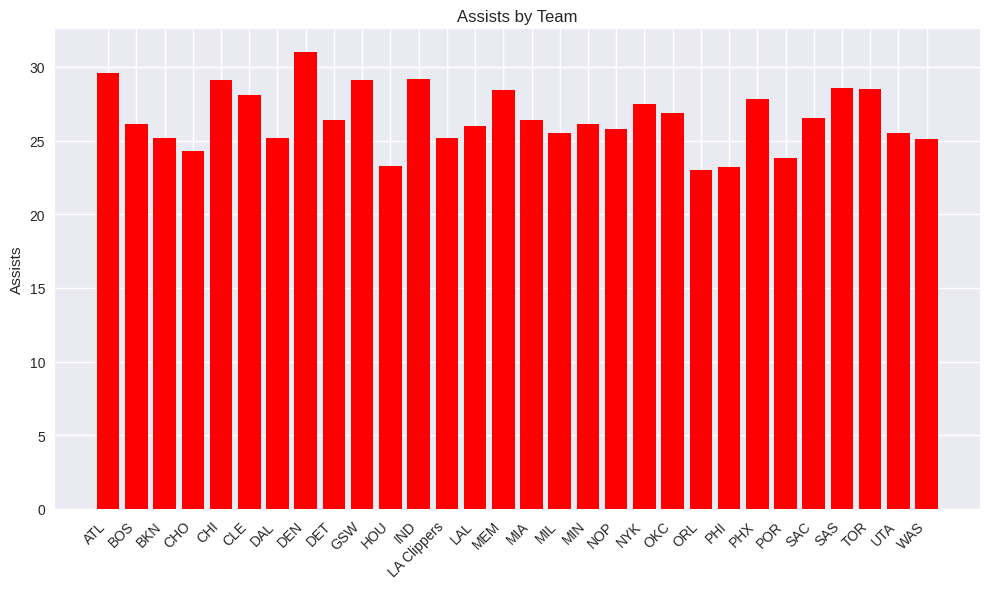

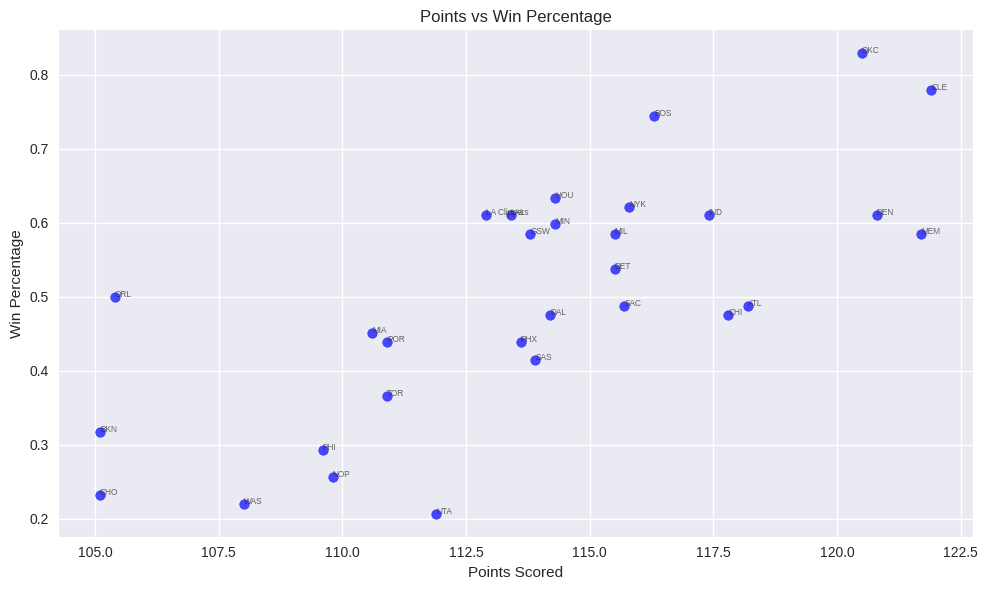

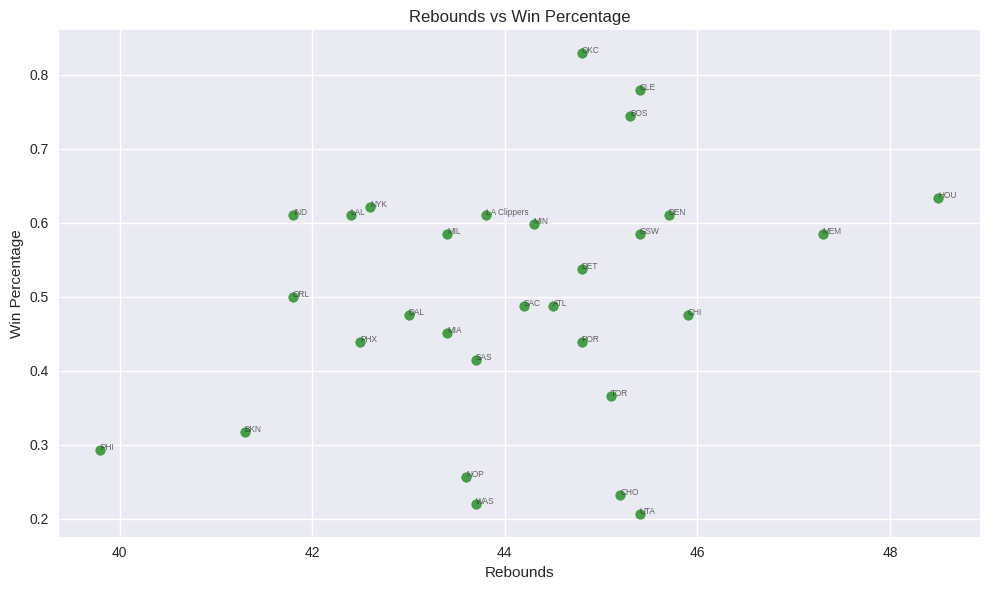

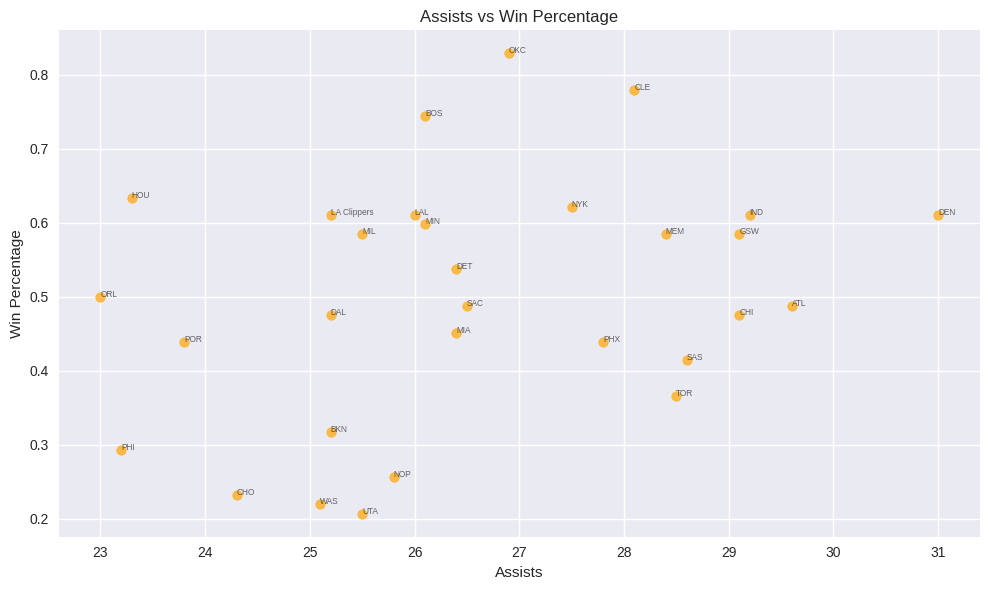

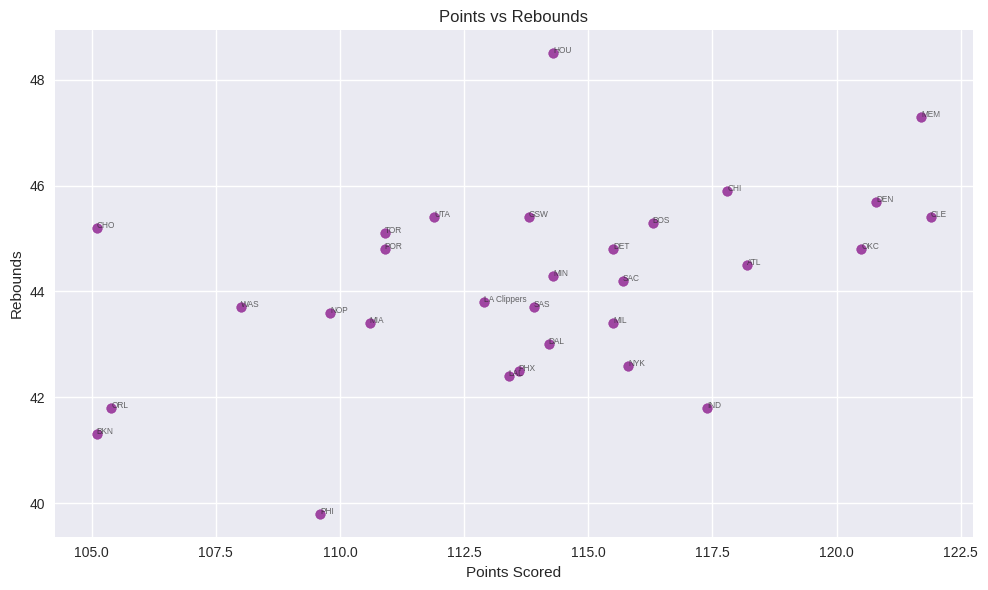

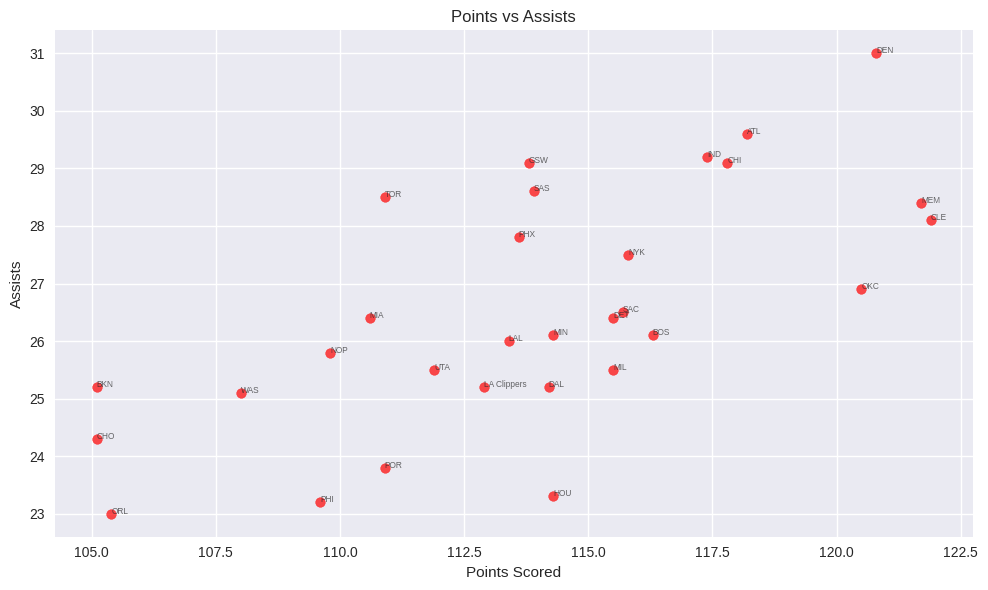

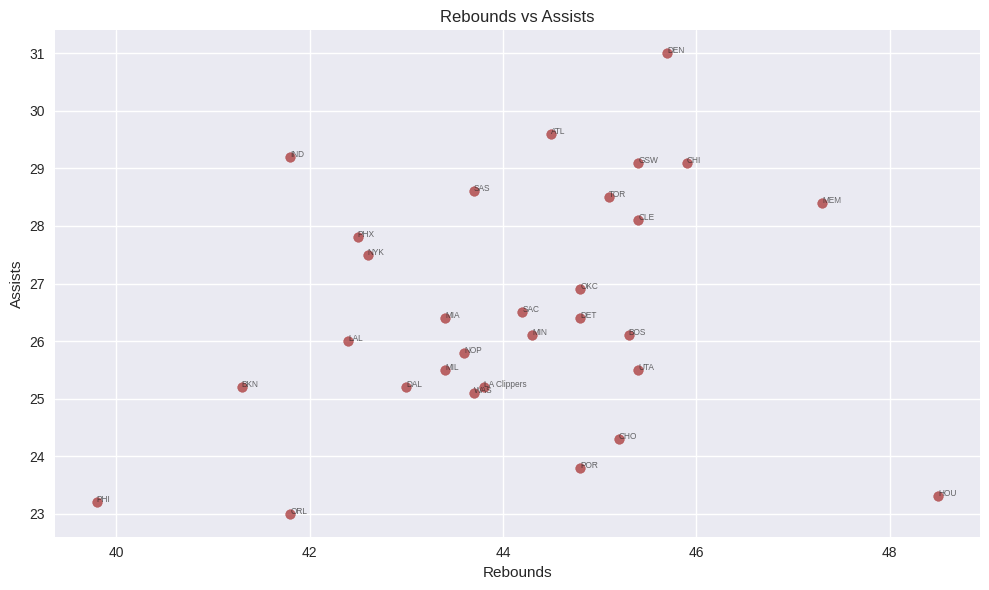

Team Statistics Summary (Sorted by Wins):
                 TEAM_NAME  TEAM_ABBREV   W   L  W_PCT    PTS   REB   AST
20   Oklahoma City Thunder          OKC  68  14  0.829  120.5  44.8  26.9
5      Cleveland Cavaliers          CLE  64  18  0.780  121.9  45.4  28.1
1           Boston Celtics          BOS  61  21  0.744  116.3  45.3  26.1
10         Houston Rockets          HOU  52  30  0.634  114.3  48.5  23.3
19         New York Knicks          NYK  51  31  0.622  115.8  42.6  27.5
12             LA Clippers  LA Clippers  50  32  0.610  112.9  43.8  25.2
13      Los Angeles Lakers          LAL  50  32  0.610  113.4  42.4  26.0
11          Indiana Pacers          IND  50  32  0.610  117.4  41.8  29.2
7           Denver Nuggets          DEN  50  32  0.610  120.8  45.7  31.0
17  Minnesota Timberwolves          MIN  49  33  0.598  114.3  44.3  26.1
14       Memphis Grizzlies          MEM  48  34  0.585  121.7  47.3  28.4
9    Golden State Warriors          GSW  48  34  0.585  113.8  45.4  2

In [10]:

# Check if CSV exists, if not fetch and save data
import os
if not os.path.exists('nba_team_data.csv'):
    print("Fetching data from API...")
    team_data = get_and_save_team_data()
    if team_data is None:
        print("Failed to retrieve data. Exiting.")
        exit()
else:
    print("Loading data from CSV...")
    team_data = pd.read_csv('nba_team_data.csv')
    print("Data loaded successfully")

print("\nAvailable columns:")
print(team_data.columns.tolist())
print("\nFirst few rows of data:")
print(team_data.head())

clean_data = []

column_mapping = {
    'TEAM_NAME': 'TEAM_NAME',
    'GP': 'GP',
    'W': 'W',
    'L': 'L',
    'W_PCT': 'W_PCT', 
    'PTS': 'PTS',
    'REB': 'REB',
    'AST': 'AST',
    'FG_PCT': 'FG_PCT',
    'FT_PCT': 'FT_PCT',
    'OPP_PTS': 'OPP_PTS'
}

# Create abbreviation 
team_abbreviations = {
    'Atlanta Hawks': 'ATL',
    'Boston Celtics': 'BOS',
    'Brooklyn Nets': 'BKN',
    'Charlotte Hornets': 'CHO',
    'Chicago Bulls': 'CHI',
    'Cleveland Cavaliers': 'CLE',
    'Dallas Mavericks': 'DAL',
    'Denver Nuggets': 'DEN',
    'Detroit Pistons': 'DET',
    'Golden State Warriors': 'GSW',
    'Houston Rockets': 'HOU',
    'Indiana Pacers': 'IND',
    'Los Angeles Clippers': 'LAC',
    'Los Angeles Lakers': 'LAL',
    'Memphis Grizzlies': 'MEM',
    'Miami Heat': 'MIA',
    'Milwaukee Bucks': 'MIL',
    'Minnesota Timberwolves': 'MIN',
    'New Orleans Pelicans': 'NOP',
    'New York Knicks': 'NYK',
    'Oklahoma City Thunder': 'OKC',
    'Orlando Magic': 'ORL',
    'Philadelphia 76ers': 'PHI',
    'Phoenix Suns': 'PHX',
    'Portland Trail Blazers': 'POR',
    'Sacramento Kings': 'SAC',
    'San Antonio Spurs': 'SAS',
    'Toronto Raptors': 'TOR',
    'Utah Jazz': 'UTA',
    'Washington Wizards': 'WAS'
}

for _, row in team_data.iterrows():
    team_name = row.get('TEAM_NAME', 'Unknown')
    abbrev = team_abbreviations.get(team_name, team_name)
    clean_row = {
        'TEAM_NAME': team_name,
        'TEAM_ABBREV': abbrev,
        'GP': row.get('GP', 0),
        'W': row.get('W', 0),
        'L': row.get('L', 0),
        'W_PCT': row.get('W_PCT', 0),  
        'PTS': row.get('PTS', 0),
        'REB': row.get('REB', 0),
        'AST': row.get('AST', 0),
        'FG_PCT': row.get('FG_PCT', 0),
        'FT_PCT': row.get('FT_PCT', 0),
        'OPP_PTS': row.get('OPP_PTS', 0)
    }
    clean_data.append(clean_row)

clean_df = pd.DataFrame(clean_data)

clean_df['W_PCT'] = pd.to_numeric(clean_df['W_PCT'], errors='coerce')

# Create the visualization
fig, axes = None, None

# 1. Team Performance by Wins
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['W'], color='skyblue')
plt.title('Wins by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Wins')
plt.tight_layout()
plt.show()

# 2. Team Performance by Losses
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['L'], color='lightcoral')
plt.title('Losses by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Losses')
plt.tight_layout()
plt.show()

# 3. Team Performance by Win Percentage
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['W_PCT'], color='lightgreen')
plt.title('Win Percentage by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Win Percentage')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 4. Points Scored by Team
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['PTS'], color='orange')
plt.title('Points Scored by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Points')
plt.tight_layout()
plt.show()

# 5. Rebounds by Team
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['REB'], color='purple')
plt.title('Rebounds by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Rebounds')
plt.tight_layout()
plt.show()

# 6. Assists by Team
plt.figure(figsize=(10, 6))
plt.bar(range(len(clean_df)), clean_df['AST'], color='red')
plt.title('Assists by Team')
plt.xticks(range(len(clean_df)), clean_df['TEAM_ABBREV'], rotation=45, ha='right')
plt.ylabel('Assists')
plt.tight_layout()
plt.show()

# 7. Points vs Win Percentage
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['PTS'], clean_df['W_PCT'], alpha=0.7, color='blue')
plt.title('Points vs Win Percentage')
plt.xlabel('Points Scored')
plt.ylabel('Win Percentage')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['PTS'].iloc[i], clean_df['W_PCT'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Rebounds vs Win Percentage
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['REB'], clean_df['W_PCT'], alpha=0.7, color='green')
plt.title('Rebounds vs Win Percentage')
plt.xlabel('Rebounds')
plt.ylabel('Win Percentage')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['REB'].iloc[i], clean_df['W_PCT'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

# 9. Assists vs Win Percentage
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['AST'], clean_df['W_PCT'], alpha=0.7, color='orange')
plt.title('Assists vs Win Percentage')
plt.xlabel('Assists')
plt.ylabel('Win Percentage')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['AST'].iloc[i], clean_df['W_PCT'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

# 10. Points vs Rebounds
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['PTS'], clean_df['REB'], alpha=0.7, color='purple')
plt.title('Points vs Rebounds')
plt.xlabel('Points Scored')
plt.ylabel('Rebounds')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['PTS'].iloc[i], clean_df['REB'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

# 11. Points vs Assists
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['PTS'], clean_df['AST'], alpha=0.7, color='red')
plt.title('Points vs Assists')
plt.xlabel('Points Scored')
plt.ylabel('Assists')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['PTS'].iloc[i], clean_df['AST'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

# 12. Rebounds vs Assists
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['REB'], clean_df['AST'], alpha=0.7, color='brown')
plt.title('Rebounds vs Assists')
plt.xlabel('Rebounds')
plt.ylabel('Assists')
for i, abbrev in enumerate(clean_df['TEAM_ABBREV']):
    plt.annotate(abbrev, (clean_df['REB'].iloc[i], clean_df['AST'].iloc[i]), 
                 fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()


# Print summary statistics sorted by wins
print("Team Statistics Summary (Sorted by Wins):")
team_summary = clean_df[['TEAM_NAME', 'TEAM_ABBREV', 'W', 'L', 'W_PCT', 'PTS', 'REB', 'AST']].sort_values('W', ascending=False)
print(team_summary)
print(f"\nTotal Teams Analyzed: {len(clean_df)}")
print(f"Average Win Percentage: {clean_df['W_PCT'].mean():.3f}")
print(f"Average Points Scored: {clean_df['PTS'].mean():.1f}")
print(f"Average Rebounds: {clean_df['REB'].mean():.1f}")
print(f"Average Assists: {clean_df['AST'].mean():.1f}")

# Print additional statistics
print(f"\nHighest Win Percentage: {clean_df['W_PCT'].max():.3f}")
print(f"Lowest Win Percentage: {clean_df['W_PCT'].min():.3f}")
print(f"Highest Points Scored: {clean_df['PTS'].max()}")
print(f"Lowest Points Scored: {clean_df['PTS'].min()}")

# Save the cleaned data to CSV for future use
clean_df.to_csv('nba_team_data_clean.csv', index=False)
print("\nCleaned data saved to 'nba_team_data_clean.csv'")
